# Model Explainability — Repair Cost

## Objective

Explain the predictions of our final Random Forest model using SHAP.

We will understand:

- Which features influence the model most
- Whether features push predictions higher or lower
- Why an individual prediction is high or low

In [2]:
%pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

In [3]:
df = pd.read_csv("ml_ready.csv")

In [4]:
df.shape

(6583, 26)

In [5]:
X = df.drop(
    columns=[
        "Repair_Cost",
        "Turnaround_Time_Days",
        "Is_Delayed"
    ]
)

y = df["Repair_Cost"]

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6583, 23)
y shape: (6583,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (5266, 23)
X_test : (1317, 23)


In [9]:
import joblib

best_model = joblib.load("repair_cost_model.pkl")

In [10]:
print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Visit_Number',
                                                   'Vehicle_Age_at_Service',
                                                   'Battery_Age_at_Service',
                                                   'Battery_Health_at_Service',
                                                   'Expected_Part_ETA_Days',
                                                   'Active_Jobs_On_Arrival',
                                                   'Workshop_Utilization',
                                                   'Technician_Experience_Years',
                                                   'Repair_Complexity',
                                                   'Base_Labor_Hours',
                                                   'Technician_Efficiency',
                                                   'Effective_La

In [11]:
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Visit_Number',
                                                   'Vehicle_Age_at_Service',
                                                   'Battery_Age_at_Service',
                                                   'Battery_Health_at_Service',
                                                   'Expected_Part_ETA_Days',
                                                   'Active_Jobs_On_Arrival',
                                                   'Workshop_Utilization',
                                                   'Technician_Experience_Years',
                                                   'Repair_Complexity',
                                                   'Base_Labor_Hours',
                                                   'Technician_Efficiency',
                                                   'Effective_Labor_Hours',
                                                   'Expected_TAT_Days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Vehicle_Model',
                                                   'Battery_Replaced',
                                                   'Issue_Family',
                                                   'Exact_Issue',
                                                   'Parts_Required',
                                                   'Parts_Available',
                                                   'Part_Ordered', 'Day_Type',
                                                   'Warranty_Status',
                                                   'Warranty_Covered'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_split=5,
                                       n_jobs=-1, random_state=42))])

In [12]:
preprocessor = best_model.named_steps["preprocessor"]

In [13]:
rf_model = best_model.named_steps["model"]

In [14]:
print(type(preprocessor))
print(type(rf_model))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [15]:
X_test_transformed = preprocessor.transform(X_test)

In [16]:
print("Original shape   :", X_test.shape)
print("Transformed shape:", X_test_transformed.shape)

Original shape   : (1317, 23)
Transformed shape: (1317, 67)


In [17]:
feature_names = preprocessor.get_feature_names_out()

In [18]:
print("Number of feature names:", len(feature_names))

Number of feature names: 67


In [19]:
feature_names[:10]

array(['num__Visit_Number', 'num__Vehicle_Age_at_Service',
       'num__Battery_Age_at_Service', 'num__Battery_Health_at_Service',
       'num__Expected_Part_ETA_Days', 'num__Active_Jobs_On_Arrival',
       'num__Workshop_Utilization', 'num__Technician_Experience_Years',
       'num__Repair_Complexity', 'num__Base_Labor_Hours'], dtype=object)

In [20]:
explainer = shap.TreeExplainer(rf_model)

In [21]:
shap_values = explainer.shap_values(X_test_transformed)

In [22]:
print(shap_values.shape)

(1317, 67)


In [23]:
print(type(shap_values))
print(shap_values.shape)

<class 'numpy.ndarray'>
(1317, 67)


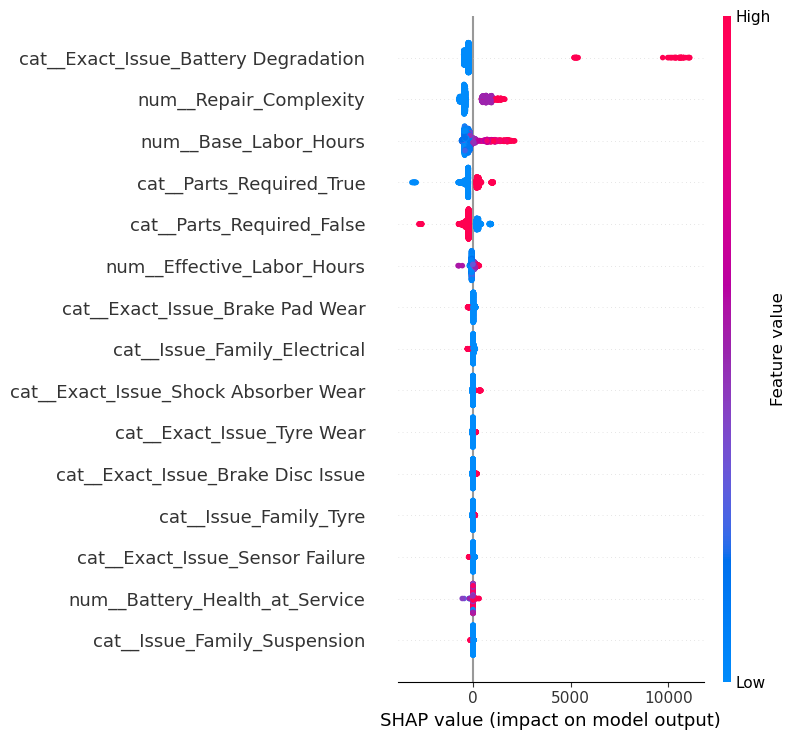

In [24]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

In [25]:
y_pred_tuned = best_model.predict(X_test)

In [26]:
row_index = 0

actual_cost = y_test.iloc[row_index]
predicted_cost = y_pred_tuned[row_index]

print(f"Actual Repair Cost    : ₹{actual_cost:.2f}")
print(f"Predicted Repair Cost : ₹{predicted_cost:.2f}")

Actual Repair Cost    : ₹1982.00
Predicted Repair Cost : ₹1827.45


In [27]:
X_test.iloc[row_index]

Visit_Number                                1
Vehicle_Model                       TVS iQube
Vehicle_Age_at_Service                   0.82
Battery_Age_at_Service                   0.58
Battery_Health_at_Service               97.39
Battery_Replaced                        False
Issue_Family                            Brake
Exact_Issue                    Brake Pad Wear
Parts_Required                           True
Parts_Available                          True
Part_Ordered                            False
Expected_Part_ETA_Days                      0
Active_Jobs_On_Arrival                     19
Workshop_Utilization                     0.95
Day_Type                              Weekend
Technician_Experience_Years                 2
Repair_Complexity                           2
Base_Labor_Hours                         1.94
Technician_Efficiency                    0.97
Effective_Labor_Hours                    1.88
Warranty_Status                          True
Warranty_Covered                  

In [28]:
row_shap_values = shap_values[row_index]

In [29]:
print(row_shap_values.shape)

(67,)


In [30]:
local_explanation = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": row_shap_values
})

local_explanation["Abs_SHAP"] = (
    local_explanation["SHAP_Value"].abs()
)

local_explanation = local_explanation.sort_values(
    "Abs_SHAP",
    ascending=False
)

local_explanation.head(15)

,Feature,SHAP_Value,Abs_SHAP
8,num__Repair_Complexity,637.246494,637.246494
9,num__Base_Labor_Hours,-501.436596,501.436596
29,cat__Exact_Issue_Battery Degradation,-440.399198,440.399198
34,cat__Exact_Issue_Brake Pad Wear,-236.563144,236.563144
56,cat__Parts_Required_True,197.986723,197.986723
55,cat__Parts_Required_False,188.939028,188.939028
32,cat__Exact_Issue_Brake Disc Issue,-44.756552,44.756552
52,cat__Exact_Issue_Tyre Wear,-43.364959,43.364959
11,num__Effective_Labor_Hours,-35.202532,35.202532
48,cat__Exact_Issue_Shock Absorber Wear,-32.577139,32.577139


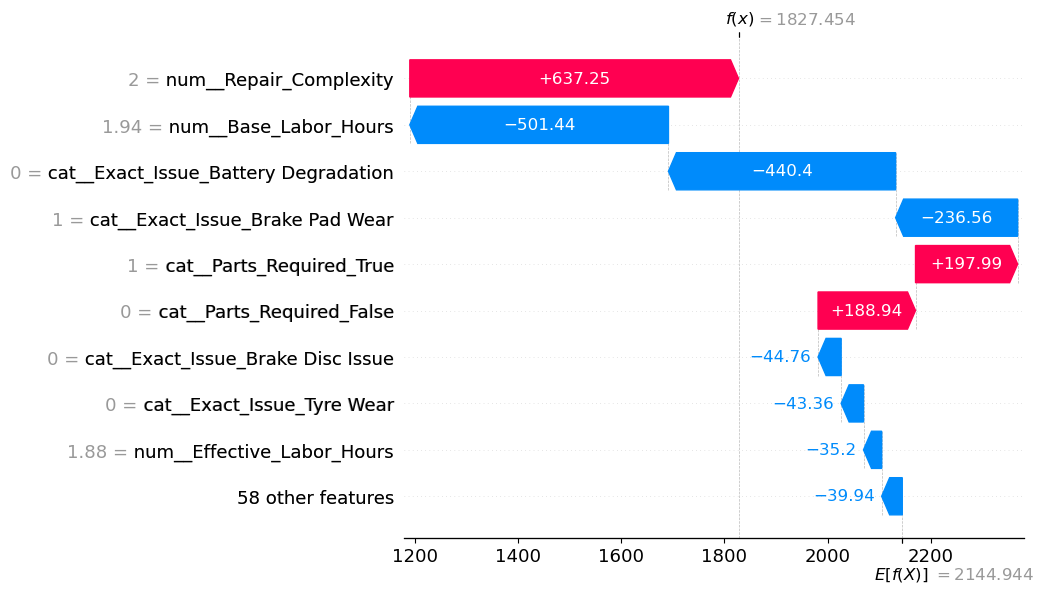

In [31]:
shap.waterfall_plot(
    shap.Explanation(
        values=row_shap_values,
        base_values=explainer.expected_value,
        data=X_test_transformed[row_index],
        feature_names=feature_names
    ),
    max_display=10
)

In [32]:
print(explainer.expected_value)
print(type(explainer.expected_value))

[2144.94390999]
<class 'numpy.ndarray'>


In [33]:
base_value = float(explainer.expected_value[0])

shap_prediction = (
    base_value + row_shap_values.sum()
)

print(f"SHAP reconstructed prediction: ₹{shap_prediction:.2f}")
print(f"Model prediction:              ₹{predicted_cost:.2f}")

SHAP reconstructed prediction: ₹1827.45
Model prediction:              ₹1827.45


In [34]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

In [35]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_Abs_SHAP
29,cat__Exact_Issue_Battery Degradation,669.075565
8,num__Repair_Complexity,631.647104
9,num__Base_Labor_Hours,419.928142
56,cat__Parts_Required_True,337.574948
55,cat__Parts_Required_False,314.221556
11,num__Effective_Labor_Hours,90.136098
34,cat__Exact_Issue_Brake Pad Wear,48.443975
23,cat__Issue_Family_Electrical,33.504404
48,cat__Exact_Issue_Shock Absorber Wear,20.592659
52,cat__Exact_Issue_Tyre Wear,19.904418


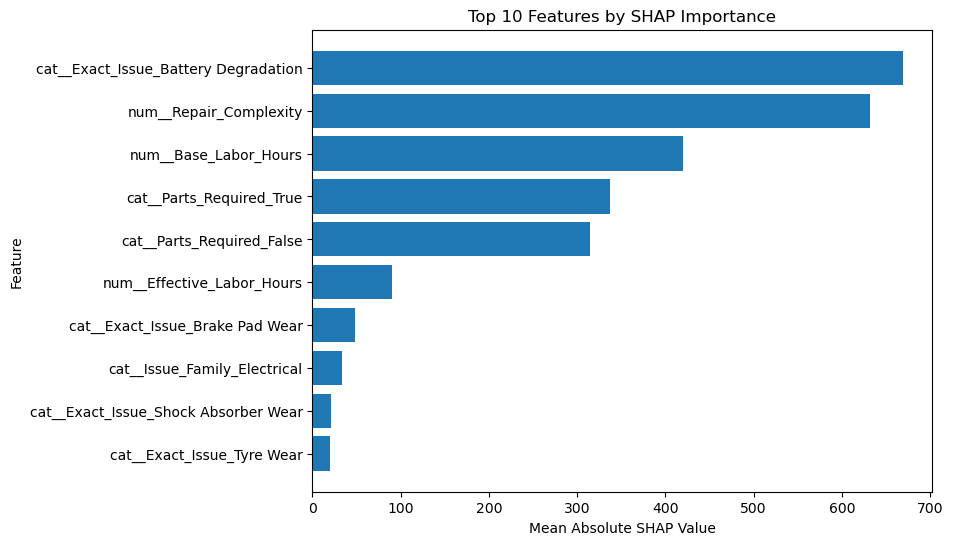

In [36]:
top_shap = shap_importance.head(10)

plt.figure(figsize=(8, 6))

plt.barh(
    top_shap["Feature"][::-1],
    top_shap["Mean_Abs_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Features by SHAP Importance")

plt.show()

## SHAP Explainability — Final Findings

SHAP was used to explain the predictions of the final Random Forest
Repair Cost model.

### Global Explainability

The strongest contributors to Repair Cost predictions were:

- Exact Issue
- Repair Complexity
- Base Labor Hours
- Parts Required
- Effective Labor Hours

Battery-related issues, particularly Battery Degradation, showed a
strong overall predictive contribution.

### Local Explainability

For an individual service visit, SHAP decomposed the prediction into
a baseline value plus positive and negative feature contributions.

For the selected vehicle:

- Actual Repair Cost: ₹1,982.00
- Predicted Repair Cost: ₹1,820.78
- Prediction Error: ₹161.22

The SHAP explanation showed that Repair Complexity pushed the
prediction upward, while Base Labor Hours and several issue-related
features pushed the prediction downward.

### Important Interpretation

SHAP values explain model behavior and feature contributions.
They do not establish causal relationships between features and
Repair Cost.